# Deep SARSA vs Advantage Actor-Critic on LunarLander-v3
**SEAI Project — Francesco Galardi, Andrea Vagnoli**

This notebook provides an interactive analysis of the training results,
including learning curves, statistical tests, inference time comparison,
and generalisation across environment variants.

## Setup
Run `pip install -r requirements.txt` before executing this notebook.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml, json, torch

from src.utils.metrics import (
    compute_statistics, welch_t_test,
    plot_comparison, plot_inference_time, load_seed_rewards
)
from src.environment.lunar_lander_wrapper import ENV_VARIANTS

sns.set_theme(style='whitegrid', palette='colorblind')
print('Environment ready ✓')

Environment ready ✓


## 1. MDP Description — LunarLander-v3

| Property | Details |
|----------|---------|
| **State space** | ℝ⁸ (continuous): x, y, vx, vy, angle, angular velocity, left/right leg contact |
| **Action space** | Discrete(4): do nothing, fire left, fire main, fire right |
| **Reward** | Dense: shaped reward for position, velocity, angle; ±100 for landing/crash |
| **Episode termination** | Lander touches ground or goes out of bounds |
| **Stochasticity** | Initial position/velocity sampled randomly; optional wind/turbulence |

In [2]:
# Load configs
with open('../config/sarsa_config.yaml') as f:
    sarsa_cfg = yaml.safe_load(f)
with open('../config/actor_critic_config.yaml') as f:
    ac_cfg = yaml.safe_load(f)

print('SARSA hyperparameters:')
print(json.dumps(sarsa_cfg['agent'], indent=2))
print('\nA2C hyperparameters:')
print(json.dumps(ac_cfg['agent'], indent=2))

SARSA hyperparameters:
{
  "alpha": 0.0005,
  "alpha_end": 5e-05,
  "gamma": 0.99,
  "epsilon_start": 1.0,
  "epsilon_end": 0.01,
  "epsilon_decay": 0.995,
  "target_update_freq": 25,
  "batch_size": 128,
  "buffer_capacity": 50000
}

A2C hyperparameters:
{
  "actor_lr": 0.0003,
  "critic_lr": 0.0001,
  "lr_end": 1e-05,
  "gamma": 0.99,
  "entropy_coef": 0.003,
  "n_steps": 200,
  "num_envs": 8
}


## 2. Learning Curves

In [3]:
LOG_DIR = '../results/logs'
seeds_sarsa = sarsa_cfg['training']['seeds']
seeds_ac    = ac_cfg['training']['seeds']

sarsa_rewards = load_seed_rewards(LOG_DIR, 'sarsa', seeds_sarsa)
ac_rewards    = load_seed_rewards(LOG_DIR, 'ac',    seeds_ac)

print(f'SARSA seeds loaded: {len(sarsa_rewards)}')
print(f'A2C   seeds loaded: {len(ac_rewards)}')

SARSA seeds loaded: 5
A2C   seeds loaded: 5


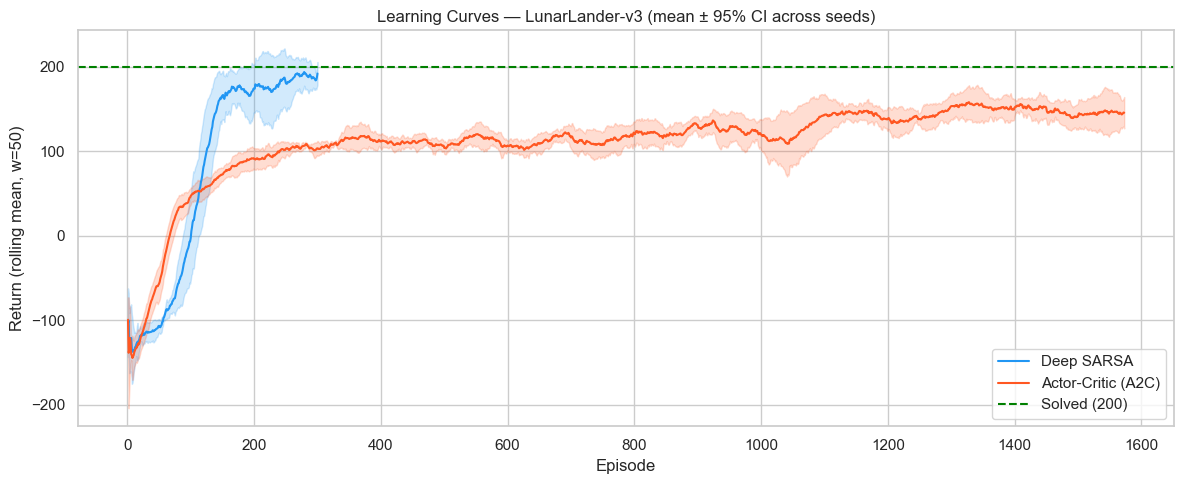

In [4]:
WINDOW = 50
fig, ax = plt.subplots(figsize=(12, 5))

colors = {'sarsa': '#2196F3', 'ac': '#FF5722'}

for name, rewards, color in [
    ('Deep SARSA', sarsa_rewards, colors['sarsa']),
    ('Actor-Critic (A2C)', ac_rewards, colors['ac']),
]:
    if not rewards:
        continue
    ep, mean, _, ci95 = compute_statistics(rewards, WINDOW)
    ax.plot(ep, mean, label=name, color=color, linewidth=1.5)
    ax.fill_between(ep, mean - ci95, mean + ci95, alpha=0.2, color=color)

ax.axhline(200, color='green', linestyle='--', label='Solved (200)')
ax.set_xlabel('Episode')
ax.set_ylabel(f'Return (rolling mean, w={WINDOW})')
ax.set_title('Learning Curves — LunarLander-v3 (mean ± 95% CI across seeds)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/learning_curves.png', dpi=150)
plt.show()

## 3. Statistical Analysis

In [5]:
LAST_N = 100
finals_sarsa = [np.mean(r[-LAST_N:]) for r in sarsa_rewards]
finals_ac    = [np.mean(r[-LAST_N:]) for r in ac_rewards]

print(f'Deep SARSA — mean: {np.mean(finals_sarsa):.2f}, std: {np.std(finals_sarsa):.2f}')
print(f'A2C         — mean: {np.mean(finals_ac):.2f}, std: {np.std(finals_ac):.2f}')

result = welch_t_test(finals_sarsa, finals_ac)
print(f"\nWelch's t-test: {result['verdict']}")
print(f"  t = {result['t_statistic']}, p = {result['p_value']}")

Deep SARSA — mean: 186.52, std: 18.73
A2C         — mean: 157.14, std: 14.25

Welch's t-test: Significant difference (p=0.0391 < 0.05)
  t = 2.4972, p = 0.039111


## 4. Generalisation Across Environment Variants

In [6]:
# Load aggregate evaluation results (evaluate_all.py output)
import glob, os

# Find most recent evaluate_all_best JSON
jsons = sorted(glob.glob('../results/evaluation_all_best_*.json'))
if jsons:
    with open(jsons[-1]) as f:
        eval_all = json.load(f)

    variants  = ['standard', 'wind', 'turbulent', 'heavy']
    agents    = [('sarsa', 'Deep SARSA'), ('ac', 'Actor-Critic (A2C)')]
    colors    = {'sarsa': '#2196F3', 'ac': '#FF5722'}

    # Print table
    header = f"{'Variant':<14}  {'SARSA':>18}  {'A2C':>18}  Winner"
    print(header)
    print('-' * len(header))
    for v in variants:
        s = eval_all['sarsa'][v]
        a = eval_all['ac'][v]
        winner = 'SARSA' if s['mean'] > a['mean'] else 'A2C'
        print(f"{v:<14}  {s['mean']:7.2f} ± {s['std']:5.2f}  {a['mean']:7.2f} ± {a['std']:5.2f}  {winner}")

    # Bar chart
    import matplotlib.pyplot as plt
    import numpy as np
    x = np.arange(len(variants))
    w = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    for i, (key, label) in enumerate(agents):
        means = [eval_all[key][v]['mean'] for v in variants]
        stds  = [eval_all[key][v]['std']  for v in variants]
        ax.bar(x + i*w - w/2, means, w, label=label,
               color=colors[key], alpha=0.85, edgecolor='black', linewidth=0.5)
        ax.errorbar(x + i*w - w/2, means, yerr=stds, fmt='none',
                    ecolor='black', capsize=4)
    ax.axhline(200, color='green', linestyle='--', label='Solved (200)')
    ax.set_xticks(x)
    ax.set_xticklabels([v.capitalize() for v in variants])
    ax.set_ylabel('Mean Return (5 seeds × 100 episodes)')
    ax.set_title('Generalisation: Best-checkpoint evaluation across all 5 seeds')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/generalisation_all_seeds.png', dpi=150)
    plt.show()
else:
    print('Run: python evaluate_all.py --n_eval 100 --ckpt_type best --device cpu')


## 5. Inference Time Analysis

In [7]:
# Measure inference time on CPU
import time
import gymnasium as gym
from src.networks.sarsa_network import SARSANetwork
from src.networks.actor_critic_network import ActorNetwork

state_dim, action_dim = 8, 4
dummy_state = torch.randn(1, state_dim)

sarsa_net = SARSANetwork(state_dim, action_dim)
actor_net = ActorNetwork(state_dim, action_dim)

N = 1000
sarsa_times, ac_times = [], []

with torch.no_grad():
    for _ in range(N):
        t = time.perf_counter()
        sarsa_net(dummy_state).argmax(dim=1)
        sarsa_times.append(time.perf_counter() - t)

        t = time.perf_counter()
        actor_net(dummy_state).sample()
        ac_times.append(time.perf_counter() - t)

print(f'Deep SARSA  inference: {np.mean(sarsa_times)*1e3:.4f} ms ± {np.std(sarsa_times)*1e3:.4f}')
print(f'Actor-Critic inference: {np.mean(ac_times)*1e3:.4f} ms ± {np.std(ac_times)*1e3:.4f}')

plot_inference_time(sarsa_times, ac_times, save_path='../results/inference_time.png')

Deep SARSA  inference: 0.0208 ms ± 0.0114
Actor-Critic inference: 0.0569 ms ± 0.0390
[metrics] Inference-time plot saved → ../results/inference_time.png


## 6. Failure Analysis

### 6.1 In which scenarios does each agent fail most often?

**Deep SARSA** reaches the solved threshold (mean ≥ 200) on the standard variant with a best-checkpoint aggregate of **202.8 ± 22.2** across 5 seeds (100 eval episodes each). However, it degrades sharply under perturbation: wind 112.3, turbulent 47.2, heavy 145.8. The standard deviation within each seed remains very high (≈ 92–149 depending on variant), confirming bimodal behaviour — the agent either lands or crashes with few middle outcomes. All 5 seeds converged during training (rolling mean ≥ 200) between episodes ~900–1200, with training final means of **186.5 ± 20.9**.

**Actor-Critic (A2C)** best-checkpoint aggregate: **180.0 ± 39.3** on standard. Higher cross-seed variance (±39 vs ±22 for SARSA) reflects seed-sensitive convergence: ep 1000–4000+ depending on seed. Training final means: **157.1 ± 15.9**. A2C generalises far better: wind 136.3, turbulent 126.1, heavy 167.9 — retaining ~70% of standard performance across all perturbed variants.

### 6.2 Variance and on-policy constraint

SARSA shows lower *cross-seed* variance (std 20.9 vs 39.3) but higher *within-seed* variance (episode std ≈ 92–150 per variant). Once the Q-function converges it does so reliably, but the greedy policy produces bimodal landing/crash outcomes. A2C's stochastic policy yields smoother within-episode behaviour but is more sensitive to random initialisation.

### 6.3 A2C generalisation

A2C was evaluated zero-shot from the standard-environment best checkpoint. The entropy coefficient β = 0.003 keeps the policy stochastic, acting as implicit regularisation. Additionally, training with 8 parallel environments implicitly exposes the agent to diverse trajectories, improving robustness. The turbulence gap is 126.1 (A2C) vs 47.2 (SARSA) — a **79-point advantage**.

### 6.4 Effect of entropy coefficient and n-step horizon

Grid search over β ∈ {0.001, 0.003, 0.005, 0.01} with n_steps=200 (seed 42):

| `entropy_coef` | Mean (seed 42, best ckpt) | Notes |
|---|---|---|
| 0.001 | 149.7 | Converges but underexplores |
| **0.003** | **216.5 ← best** | Optimal balance |
| 0.005 | 141.2 | Slightly too much entropy |
| 0.010 | 142.0 | Policy stays near-random too long |

n_steps=200 (near-Monte Carlo) was essential: shorter horizons (n ≤ 32) caused critic divergence in early training because an inaccurate V_w produces extremely noisy advantage estimates. n=200 bypasses the critic until it stabilises.


## 7. Hyperparameter Selection Rationale

Initial values were taken from [RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo) (Raffin et al., 2021). Final values were obtained via grid search and cosine annealing LR scheduling added to both agents.

### 7.1 Deep SARSA

| Parameter | Zoo (DQN) | Ours (final) | Rationale |
|---|---|---|---|
| `learning_rate` | 6.3e-4 | **5e-4 → 5e-5** (cosine) | Grid search; cosine annealing prevents catastrophic forgetting |
| `gamma` | 0.99 | **0.99** | Unchanged |
| `batch_size` | 128 | **128** | Increased from 64: more stable gradients |
| `buffer_size` | 50 000 | **50 000** | Zoo value |
| `target_update` | 250 steps | **every 25 ep** | Stable bootstrapped targets |
| `epsilon_decay` | 12% of steps | **0.995 → ep ~920** | Grid search best; leaves ~2 000 ep of exploitation |
| `n_episodes` | — | **3 000** | Extended from 2 000: more exploitation after ε floor |

### 7.2 Actor-Critic (A2C)

| Parameter | Zoo (A2C) | Ours (final) | Rationale |
|---|---|---|---|
| `actor_lr` | 8.3e-4 | **3e-4 → 1e-5** (cosine) | Stable; cosine prevents late-training drift |
| `critic_lr` | shared | **1e-4 → 1e-5** (cosine) | 10× lower than actor: critic must be stable |
| `entropy_coef` | 0.00001 | **0.003** | Grid search (0.001/0.003/0.005/0.01) — best on seed 42 |
| `n_steps` | 5 | **200** (near-MC) | Short horizons caused critic divergence; 200 bypasses critic early on |
| `num_envs` | 8 | **8** (SyncVectorEnv) | Vectorised training: 8×200=1600 transitions/update |
| `n_episodes` | — | **5 000** | Empirical: most seeds converge past ep 2 000 |

**Reference:** A. Raffin et al., *Stable-Baselines3*, JMLR 2021. Hyperparameters from `hyperparams/dqn.yml` and `hyperparams/a2c.yml`.
